# AutoEconSentiment Demo
This notebook demonstrates the basics of the `AutoEconSentiment` pipeline: loading data, cleaning it, and running lexical sentiment analysis.

In [2]:
import os
import pandas as pd
from auto_econ_sentiment.pipeline import AutoEconSentiment

# Ensure we are in the project root if running from notebooks directory
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

## 1. Setup Data
We will use a sample FOMC dataset included in the repository.

In [3]:
import_file_path = "data/raw/basic_tests/monetary_policy_statement.parquet.gzip"
export_path = "data/sentiment/demo_run/"

analyzer = AutoEconSentiment(
    import_file_path=import_file_path,
    text_column="text",
    date_column="date",
    export_path=export_path
)

In [4]:
df_raw = analyzer.load_data()
df_raw.head(2)

,Unnamed: 0,date,text,type,event,link,title,speaker,text_len,release_date
245,0,1994-02-04,Chairman Alan Greenspan announced today that t...,Policy Statement,Policy Statement,https://www.federalreserve.gov/fomc/19940322de...,None,None,NaN,1994-02-04
246,1,1994-03-22,Chairman Alan Greenspan announced today that t...,Policy Statement,Policy Statement,https://www.federalreserve.gov/fomc/19940204de...,None,None,NaN,1994-03-22


## 2. Run Pipeline
We run the cleaning and sentiment scoring in one go using the `run()` method.

## 2.A Run pipeline

In [22]:
df_raw, df_clean, df_sentiment = analyzer.run(
    clean_config={"tokenize": True, "stem": True},
    dictionaries={
        "unstemmed": ["correa", "hubert", "lm", "hiv"],
        "stemmed": ["ap", "bn"]
        },
    aggregation_methods=["posneg", "allwords"],
    export_results=True
)

df_sentiment.head()

Lexical Methods:  33%|███▎      | 2/6 [00:00<00:01,  3.67it/s]/Users/cory/Desktop/auto-econ-sentiment/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:1378: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(
/Users/cory/Desktop/auto-econ-sentiment/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:1378: UserWarning: Upper case characters found in vocabulary while 'lowercase' is True. These entries will not be matched with any documents
  warnings.warn(
Lexical Methods: 100%|██████████| 6/6 [00:01<00:00,  3.21it/s]


,correa_counttoken_positive_posneg,correa_counttoken_negative_posneg,correa_words_positive_posneg,correa_words_negative_posneg,correa_sentiment_posneg,correa_counttoken_positive_allwords,correa_counttoken_negative_allwords,correa_words_positive_allwords,correa_words_negative_allwords,correa_counttoken_total_allwords,...,bn_counttoken_negative_posneg_stem,bn_words_positive_posneg_stem,bn_words_negative_posneg_stem,bn_sentiment_posneg_stem,bn_counttoken_positive_allwords_stem,bn_counttoken_negative_allwords_stem,bn_words_positive_allwords_stem,bn_words_negative_allwords_stem,bn_counttoken_total_allwords_stem,bn_sentiment_allwords_stem
id_text,,,,,,,,,,,,,,,,,,,,,
1,0,0,{},{},1.0,0,0,{},{},26,...,1,{'increas': 2},{'small': 1},1.333333,2,1,{'increas': 2},{'small': 1},26,1.038462
2,1,0,{'enhance': 1},{},2.0,1,0,{'enhance': 1},{},56,...,1,"{'firm': 1, 'increas': 2}",{'small': 1},1.500000,3,1,"{'firm': 1, 'increas': 2}",{'small': 1},56,1.035714
3,0,0,{},{},1.0,0,0,{},{},23,...,1,{'increas': 2},{'small': 1},1.333333,2,1,{'increas': 2},{'small': 1},23,1.043478
4,2,0,"{'effective': 1, 'favorable': 1}",{},2.0,2,0,"{'effective': 1, 'favorable': 1}",{},97,...,0,{'increas': 2},{},2.000000,2,0,{'increas': 2},{},97,1.020619
5,1,0,{'contained': 1},{},2.0,1,0,{'contained': 1},{},80,...,0,{'high': 1},{},2.000000,1,0,{'high': 1},{},80,1.012500


### 2.A.A Clean data

In [23]:
df_clean.loc[:, 'release_date':].head(2)

,release_date,id_text,text_clean,text_tokens,text_tokens_str,text_stems
245,1994-02-04,1,Chairman Alan Greenspan announced today that t...,"[chairman, alan, greenspan, announced, today, ...",chairman alan greenspan announced today that t...,chairman alan greenspan announc today that the...
246,1994-03-22,2,Chairman Alan Greenspan announced today that t...,"[chairman, alan, greenspan, announced, today, ...",chairman alan greenspan announced today that t...,chairman alan greenspan announc today that the...


## 

## 2.1 Sentiment

### 2.1.1 Using positive and negative words only in the demoninator

*   **`posneg`**: Normalizes sentiment by the total count of matched sentiment words. 
    $$ \text{Sentiment}_{\text{posneg}} = 1 + \frac{N_{\text{pos}} - N_{\text{neg}}}{N_{\text{pos}} + N_{\text{neg}}} $$


<Axes: xlabel='id_text'>

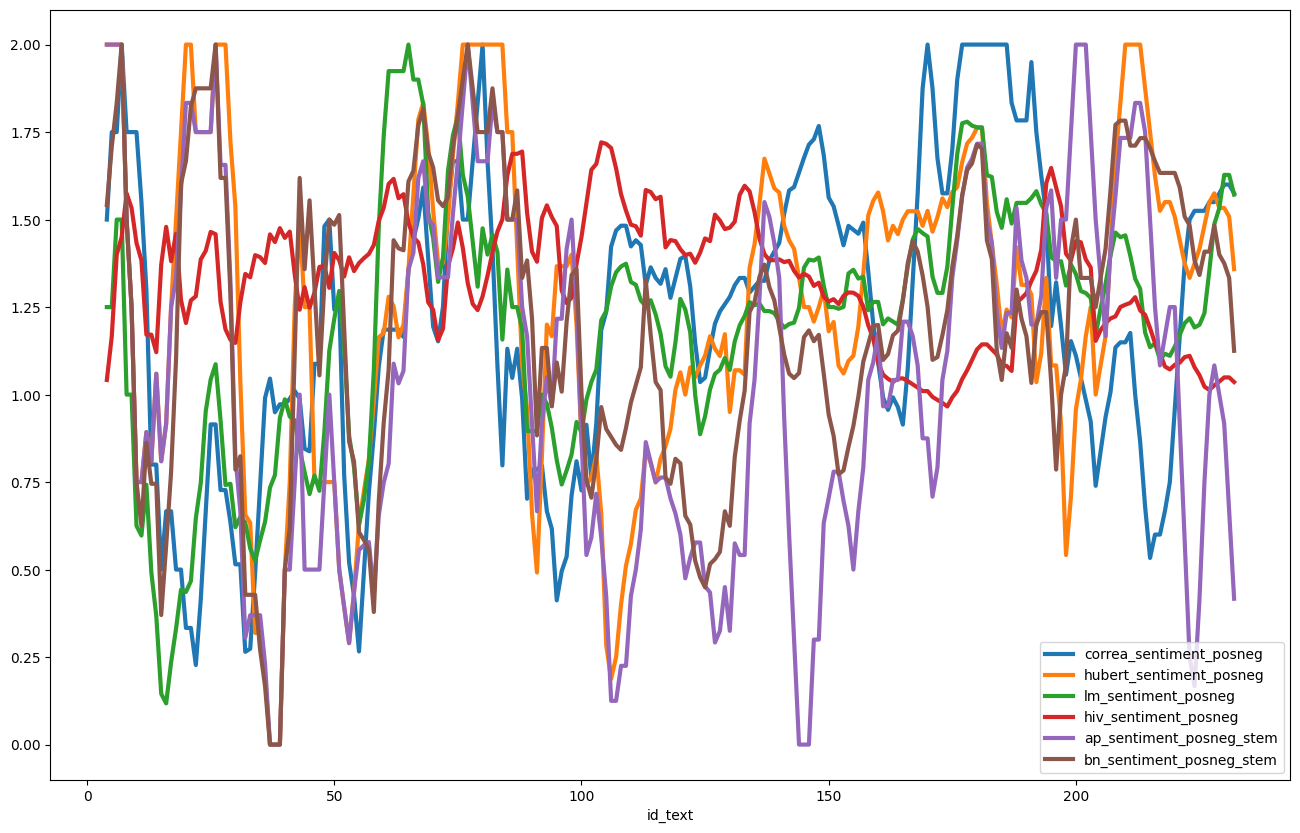

In [27]:
df_sentiment.filter(regex='sentiment_posneg').rolling(4).mean().plot(figsize = (16,10), linewidth=3)

### 2.1.2 Using ALL words only in the demoninator

<Axes: xlabel='id_text'>

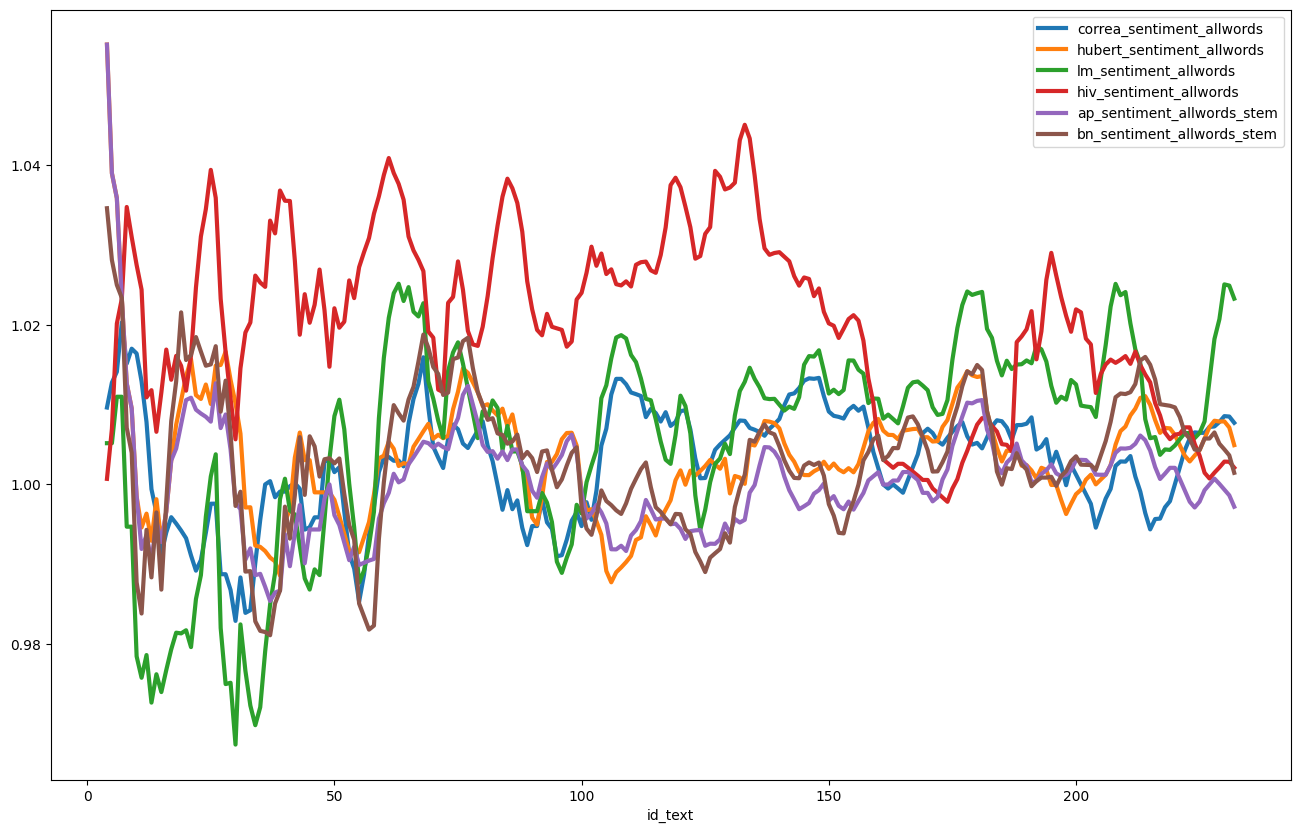

In [28]:
df_sentiment.filter(regex='sentiment_allwords').rolling(4).mean().plot(figsize = (16,10), linewidth=3)

## 2.2 Sanity Checking

The final output DataFrame contains the following core columns for each configured dictionary (e.g., `hubert`):

| Column Pattern               | Description                                                                         |
| ---------------------------- | ----------------------------------------------------------------------------------- |
| `{dict}_counttoken_positive` | Total count of positive words identified by the dictionary.                         |
| `{dict}_counttoken_negative` | Total count of negative words identified by the dictionary.                         |
| `{dict}_counttoken_total`    | Total tokens in the document (only present if using `allwords` method).             |
| `{dict}_words_positive`      | JSON-like mapping of the specific positive words found and their counts.            |
| `{dict}_words_negative`      | JSON-like mapping of the specific negative words found and their counts.            |
| `{dict}_sentiment_{method}`  | Final computed sentiment score using the specified method (`posneg` or `allwords`). |


### 2.2.A Match word count to original text

##

In [55]:
[sentence for sentence in df_clean.text_clean.iloc[-1].split(".") if "impede" in sentence][0]

" The Committee would be prepared to adjust the stance of monetary policy as appropriate if risks emerge that could impede the attainment of the Committee's goals"

In [58]:
df_sentiment.filter(regex='correa_counttoken_negative').tail(1)

,correa_counttoken_negative_posneg,correa_counttoken_negative_allwords
id_text,,
232,1,1


In [59]:
df_sentiment.filter(regex='correa_words_negative').tail(1)

,correa_words_negative_posneg,correa_words_negative_allwords
id_text,,
232,{'impede': 1},{'impede': 1}


## 2.2.1 Negative counts from both methods should be equal because aggregation only takes place in denominator

<Axes: xlabel='id_text'>

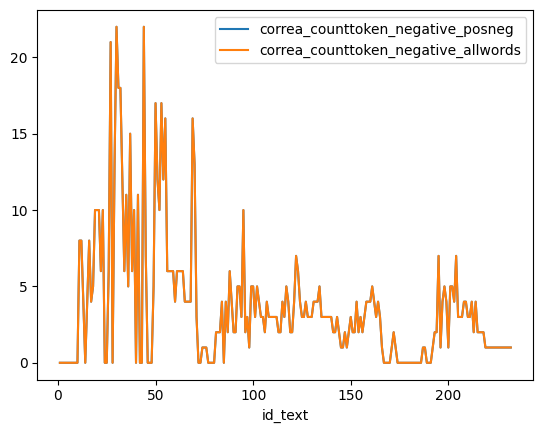

In [37]:
df_sentiment.filter(regex='correa_counttoken_negative').plot()

### 2.2 Negative word counts differ greatly by method

<Axes: xlabel='id_text'>

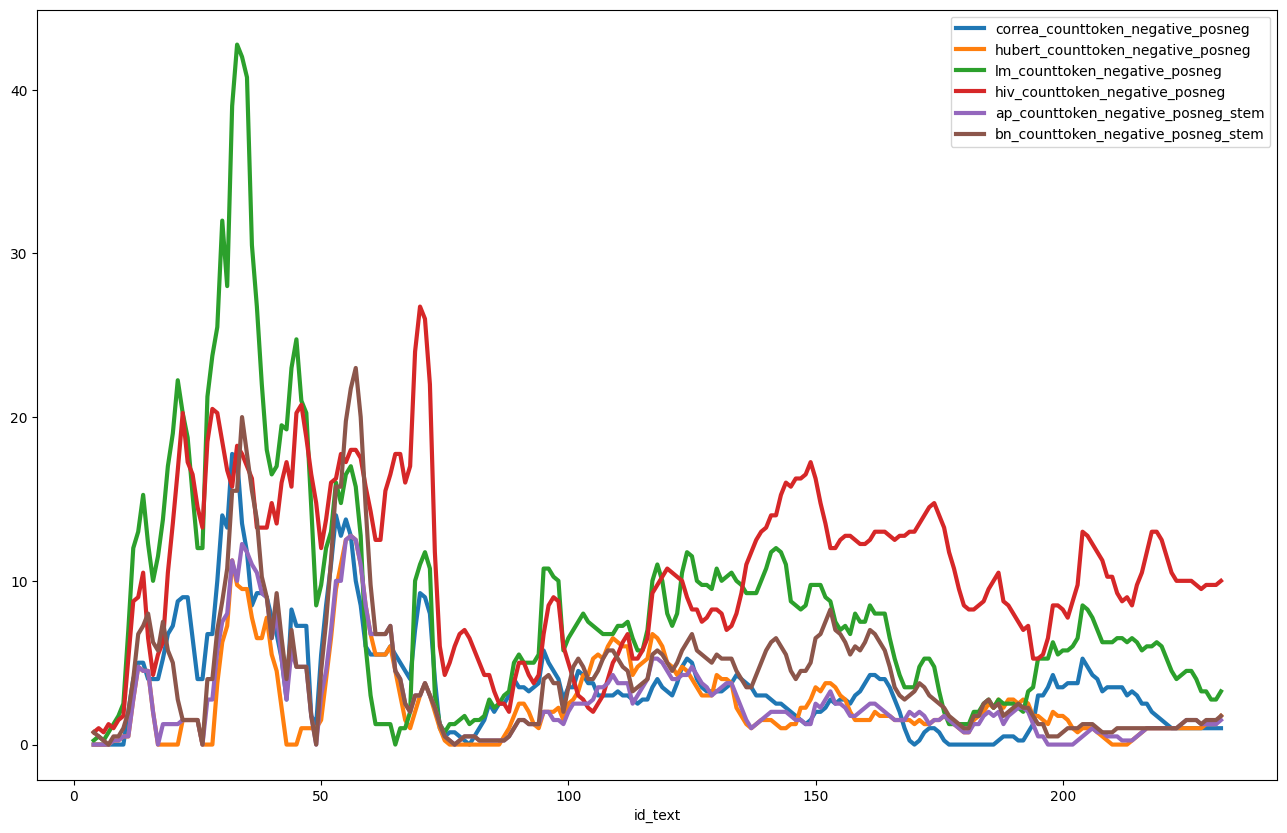

In [62]:
df_sentiment.filter(regex='counttoken_negative_posneg').rolling(4).mean().plot(figsize = (16,10), linewidth=3)

## 3. Dictionary Examples
View the words contained in a specific dictionary.

In [4]:
def show_dictionary_example(dictionary_name, limit=10):
    import yaml
    with open("src/auto_econ_sentiment/data/lexical_master_dict.yaml", "r") as f:
        master_dict = yaml.safe_load(f)
    
    if dictionary_name in master_dict:
        print(f"--- Dictionary: {dictionary_name} ---")
        pos = master_dict[dictionary_name].get('positive', [])
        neg = master_dict[dictionary_name].get('negative', [])
        print(f"Positive examples: {pos[:limit]} ... ({len(pos)} total)")
        print(f"Negative examples: {neg[:limit]} ... ({len(neg)} total)")
    else:
        print(f"Dictionary {dictionary_name} not found.")

show_dictionary_example("lm")

--- Dictionary: lm ---
Positive examples: ['able', 'abundance', 'abundant', 'acclaimed', 'accomplish', 'accomplished', 'accomplishes', 'accomplishing', 'accomplishment', 'accomplishments'] ... (354 total)
Negative examples: ['abandon', 'abandoned', 'abandoning', 'abandonment', 'abandonments', 'abandons', 'abdicated', 'abdicates', 'abdicating', 'abdication'] ... (2355 total)
